# Image Processing Technique for Counting Stitches
NOTE: Pipeline is developed upon B68G performance. Will test the pipeline on other students.

Techniques:
(https://akshaysatyam2.medium.com/10-image-processing-techniques-for-computer-vision-d3df124b803c)
- adaptive gaussian treshold (looks very good for picking up threads)
- morphological edge enhancement (https://www.geeksforgeeks.org/python/python-opencv-morphological-operations/)
- otsu's tresholding
- adaptive mean treshold

How to crop an image: (https://www.geeksforgeeks.org/python/python-pil-image-crop-method/)

NOTE: This project is mostly on the image processing for the CV to pick up the most cues as possible that we are defining. So lets experiment different methods without claude!

In [ ]:
# How to crop an image
from PIL import Image

def crop_image(file: str, name: str):
    img = Image.open(file)
    res = img.crop((827, 472, 1132, 582))
    # res = img.crop((a, b, c, d))
    # extracts from x=a-c, y=b-d
    res.save(f"/home/sov1/OpenSutureNet/final_frame/{name}.png")
    print(f"Saved to /home/sov1/OpenSutureNet/final_frame/{name}.png")

In [6]:
crop_image("/home/sov1/OpenSutureNet/final_frame/B68G.png", "B68G_cropped")

Saved to /home/sov1/OpenSutureNet/final_frame/B68G_cropped.png


In [10]:
crop_image("/home/sov1/OpenSutureNet/final_frame/A40E.png", "A40E_cropped")

Saved to /home/sov1/OpenSutureNet/final_frame/A40E_cropped.png


### Opening
Opening performs erosion followed by dialtion on a binary image. It is commonly used to remove samll noise and unwanted foreground objects while preserving the overall shape of larger objects.

Implementation:
- create 3*3 kenel to define the nerighborhood used for the morphological operation
- apply cv2.morph_open to perfrom erosion followed by dilating, removing small foreground noise while perserving larger objects

Source: https://www.geeksforgeeks.org/python/python-opencv-morphological-operations/

In [2]:
# adapt an iamge -- morphical edge enhancement
import cv2, numpy as np, matplotlib.pyplot as plt

def plot_stitch(file: str):
    """
    Opening performs erosion followed by dialtion on a binary image.
    It is commonly used to remove samll noise and unwanted foreground objects
    while preserving the overall shape of larger objects.

    Implementation:
    - create 3*3 kenel to define the nerighborhood used for the morphological operation
    - apply cv2.morph_open to perfrom erosion followed by dilating,
    removing small foreground noise while perserving larger objects
    """
    img = cv2.imread(file, 0)
    bin = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]

    k = np.ones((3, 3), np.uint8)
    opened = cv2.morphologyEx(bin, cv2.MORPH_OPEN, k)
    plt.imshow(opened, cmap='gray')
    plt.axis('on')
    plt.grid()
    plt.show()

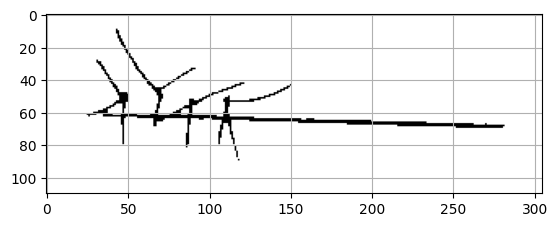

In [16]:
plot_stitch("/home/sov1/OpenSutureNet/final_frame/B68G_cropped.png")

In [4]:
# Decode to understand the function
img = cv2.imread("/home/sov1/OpenSutureNet/final_frame/B68G_cropped.png", 0)
print(img)
print(len(img))
print(len(img[0]))

[[151 151 151 ... 144 144 144]
 [151 151 151 ... 144 144 144]
 [151 151 151 ... 144 144 144]
 ...
 [157 157 157 ... 154 154 154]
 [157 157 157 ... 154 154 154]
 [157 157 157 ... 154 154 154]]
110
305


In [5]:
bin = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]
print(bin)
print(len(bin))
print(len(bin[0]))
print(bin[50])

[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]
110
305
[255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255   0   0   0   0   0   0 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255   0   0   0
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255   0   0   0 255 255 255 255 255 255 255
 255 255 255 255   0 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255   0   0   0   0 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 2

In [7]:
k = np.ones((3, 3), np.uint8)
print(k)

[[1 1 1]
 [1 1 1]
 [1 1 1]]


In [8]:
opened = cv2.morphologyEx(bin, cv2.MORPH_OPEN, k)
print(opened)
print(opened[50])

[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]
[255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255   0   0   0   0   0   0 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255   0   0   0
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255   0   0   0 255 255 255 255 255 255 255
 255 255 255 255   0 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255   0   0   0   0 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 

In [34]:
import numpy as np

np.savetxt("suture_code.txt", opened, fmt='%d')
print("Saved to suture_code.txt")

Saved to suture_code.txt


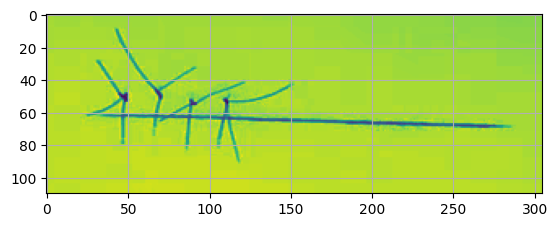

In [4]:
# read original image file
img = cv2.imread("/home/sov1/OpenSutureNet/final_frame/B68G_cropped.png", 0)
plt.imshow(img)
plt.grid()

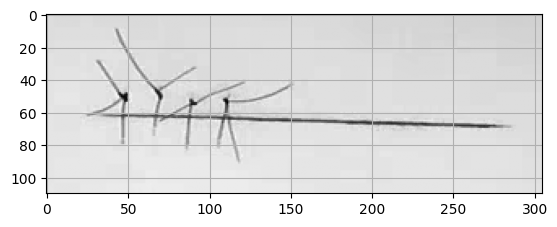

In [5]:
# read original image file
img = cv2.imread("/home/sov1/OpenSutureNet/final_frame/B68G_cropped.png", 0)
plt.imshow(img, cmap = 'gray')
plt.grid()

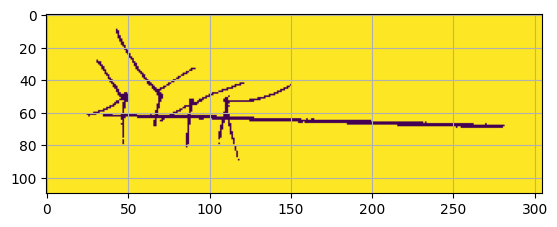

In [6]:
# turn original image to black and white
bin = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]
plt.imshow(bin)
plt.grid()

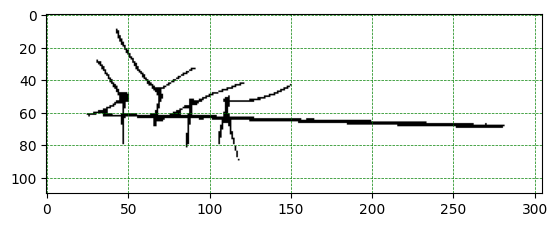

In [7]:
k = np.ones((3, 3), np.uint8)
opened = cv2.morphologyEx(bin, cv2.MORPH_OPEN, k)
plt.imshow(opened, cmap='gray')
plt.axis('image')
plt.grid(color = 'green', linestyle = '--', linewidth = 0.5)
plt.show()

### Technique to count number of stiches done

In [ ]:
# count number of stiches by observing black pixels
import numpy as np

count_line = 0
count_black_per_column = []
for x in range(0, 305):
    count_black = 0
    for y in range(0, 110):
        if opened[y][x] == 0:
            count_black += 1
    count_black_per_column.append(count_black)

print(max(count_black_per_column))
print(np.mean(count_black_per_column))
print(np.median(count_black_per_column))
print(count_black_per_column)

35
3.721311475409836
3.0
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1, 2, 2, 3, 4, 5, 5, 8, 8, 8, 6, 7, 6, 6, 6, 10, 12, 12, 18, 35, 16, 11, 10, 5, 4, 5, 5, 6, 5, 4, 4, 5, 5, 4, 5, 5, 5, 6, 11, 13, 16, 17, 13, 8, 5, 3, 3, 4, 4, 4, 6, 5, 6, 7, 7, 4, 5, 5, 15, 22, 17, 14, 7, 6, 5, 4, 5, 5, 5, 3, 4, 3, 4, 3, 5, 4, 4, 3, 11, 11, 10, 10, 17, 18, 16, 13, 10, 8, 8, 8, 5, 5, 4, 4, 3, 3, 3, 5, 5, 5, 3, 3, 4, 4, 3, 3, 4, 3, 3, 4, 3, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 3, 2, 2, 2, 2, 3, 3, 2, 2, 2, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


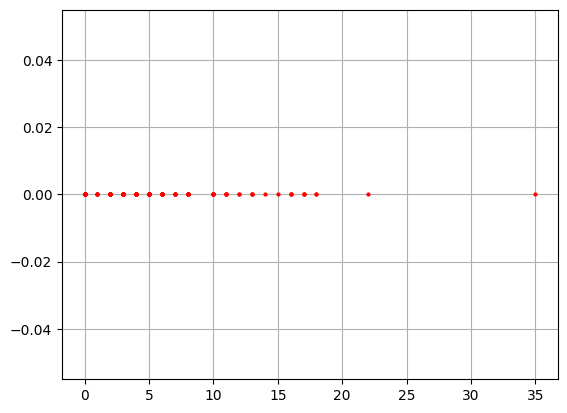

In [ ]:
# plot all the points to see outlier -- to be a standard for a plot
for x in count_black_per_column:
    plt.plot(x, 0, marker='o', markersize=2, color='red')
plt.grid()

In [63]:
# Modified from Source - https://stackoverflow.com/q/11686720
# Posted by aaren
# Retrieved 2026-07-06, License - CC BY-SA 3.0

def get_outliers(data):
    u = np.mean(data)
    s = np.std(data)
    filtered = [e for e in data if e > u + 1.5 * s]
    return np.median(filtered)

get_outliers(count_black_per_column)

np.float64(13.0)

In [64]:
# return a list of column that is larger than x
column_index = []
for i in range(0, 305):
    if count_black_per_column[i] > 13:
        column_index.append(i)
print(column_index)

[46, 47, 48, 68, 69, 86, 87, 88, 89, 110, 111, 112]


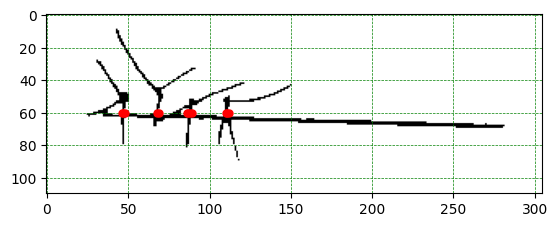

In [65]:
# plot draw a line of these columns to the plot to observe
plt.imshow(opened, cmap='gray')
plt.axis('image')
for x in column_index:
    plt.plot(x, 60, marker='o', markersize=5, color='red')
plt.grid(color = 'green', linestyle = '--', linewidth = 0.5)
plt.show()

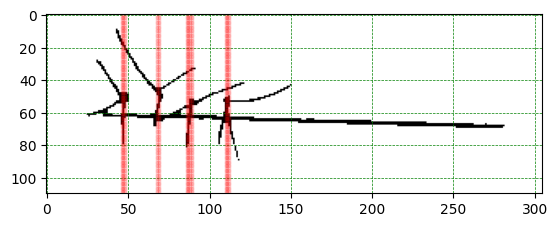

In [66]:
# plot draw a line of these columns to the plot to observe
plt.imshow(opened, cmap='gray')
plt.axis('image')
for x in column_index:
    for y in range(0, 110):
        plt.plot(x, y, marker='o', markersize=2, color='red', alpha=0.1)
plt.grid(color = 'green', linestyle = '--', linewidth = 0.5)
plt.show()

[46, 47, 48, 68, 69, 86, 87, 88, 89, 110, 111, 112]
group that we can make: 
1. [46, 47, 48] -- diff = 20
2. [68, 69] -- diff = 17
3. [86, 87, 88, 89] -- diff = 21
4. [110, 111, 112]

In [ ]:
# Count the distance of each stitch from a given list
# 1. Group them together
# input : [46, 47, 48, 68, 69, 86, 87, 88, 89, 110, 111, 112]
# output: [[46, 47, 48], [68, 69], [86, 87, 88, 89], [110, 111, 112]]
# more challenging to me than I thought

black_points = [46, 47, 48, 68, 69, 86, 87, 88, 89, 110, 111, 112]
count = len(black_points)
for i in range(0, count):
    if i + 1 < count and black_points[i] - black_points[i + 1] == 1:
        new = [black_points[i]]


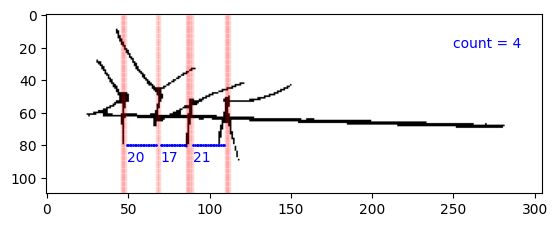

In [8]:
# plot distance
# assume that I have attained the following data
original = [46, 47, 48, 68, 69, 86, 87, 88, 89, 110, 111, 112]
grouped = [[46, 47, 48], [68, 69], [86, 87, 88, 89], [110, 111, 112]]
grouped_min_max = [[46, 48], [68, 69], [86, 89], [110, 112]]
grouped_start_end = [[48, 68], [69, 86], [89, 110]]
distance = [20, 17, 21]

plt.imshow(opened, cmap='gray')
plt.axis('image')
# plot straight red line
for x in original:
    for y in range(0, 110):
        plt.plot(x, y, marker='o', markersize=2, color='red', alpha=0.05)

# plot distance blue line
for item in grouped_start_end:
    for x in range(item[0] + 1, item[1]):
        plt.plot(x, 80, marker='o', markersize=1, color='blue')

# plot described distance
count = len(grouped)
for i in range(0, count - 1):
    plot_point = grouped_start_end[i][0]
    # plot_point = np.mean(grouped_min_max[i])
    plot_message = str(distance[i])
    plt.text(plot_point + 1, 90, plot_message, fontsize=10, color="blue")

# plot count of stitches
count_message = f"count = {len(grouped_min_max)}"
plt.text(250, 20, count_message, fontsize=10, color="blue")

plt.show()